# COMP2211 Programming Assignment 1: Cosmic Object Classification

## Introduction
The [**Sloan Digital Sky Survey (SDSS)**](https://en.wikipedia.org/wiki/Sloan_Digital_Sky_Survey) has created the most detailed three-dimensional maps of the universe ever made, with deep multi-color images of one third of the sky, and spectra for more than three million astronomical objects.

<center>
<img src="https://upload.wikimedia.org/wikipedia/commons/8/82/SDSS_Camera.jpg" width="300">
<br>
<em>(The SDSS Imaging Camera, the heart of the 2.5m Telescope. Source: Wikimedia Commons)</em>
</center>

As a Data Scientist for the survey, your mission is to automate the classification of these cosmic objects. Is that faint dot of light a star in our own Milky Way, a distant galaxy, or a Quasar powered by a supermassive black hole?

In this assignment, you will implement machine learning algorithms **from scratch** to classify these objects using photometric data.

---
### Dataset Description
You will work with a subset of the SDSS DR14 dataset. The dataset consists of photometric observations (magnitudes) and redshift data.

| Column Name | Role | Type | Description |
| :--- | :--- | :--- | :--- |
| **u, g, r, i, z** | Feature | Continuous | Photometric magnitudes in different spectral bands (Ultraviolet, Green, Red, Infrared, z-band). |
| **redshift** | Feature | Continuous | A measure of how fast an object is moving away from us (due to the expansion of the universe). Stars typically have near-zero redshift. |
| **class** | Target | Categorical | **STAR**, **GALAXY**, **QSO** (Quasar). |

## Your Mission
You will implement a "Hierarchical" approach to classification, moving from simple rules to complex models:
1.  **Data Preprocessing & Analysis**: Normalize data and visualize the "Redshift" distribution to gain physical intuition.
2.  **The Decision Stump**: A simple but powerful "One-Rule" classifier. You will distinguish Stars from Non-Stars using only the `redshift` feature.
3.  **K-Nearest Neighbors (KNN)**: A full multi-class classifier using all 6 features to distinguish Stars, Galaxies, and Quasars.
4.  **K-Means Clustering**: An unsupervised attempt to find structure in the data without labels.

---
## Task 0: Setup and Data Loading
This assignment is designed to run on **Google Colab**.

**Instructions**:
1. Upload the folder to your Google Drive.
2. Run the code cell below to mount Drive.
3. Set `DATA_PATH` to the folder containing `train.csv`.

In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Dict, Tuple, List
# Do NOT import sklearn for implementation!

# Colab-only setup
if __name__ == '__main__':
    from google.colab import drive
    drive.mount('/content/drive')

    # Set this to the folder that contains train.csv in your Drive.
    DATA_PATH = "/content/drive/MyDrive/PA1/"

    train_path = os.path.join(DATA_PATH, "train.csv")
    full_df = pd.read_csv(train_path)
    print(f"Dataset Loaded. Shape: {full_df.shape}")
    display(full_df.head())

ModuleNotFoundError: No module named 'google.colab'

## Task 1: Data Preprocessing & Visualization

### Task 1.1: Encoding and Normalization
The `class` column contains strings: 'STAR', 'GALAXY', 'QSO'. We need to convert these to integers.
Also, the photometric magnitudes and redshift have different scales. We should normalize them to the range [0, 1].

**Requirements:**
1.  **Label Encoding**: Map the class strings to integers using the provided `class_map`.
    *   `'STAR'` $\rightarrow$ 0
    *   `'GALAXY'` $\rightarrow$ 1
    *   `'QSO'` $\rightarrow$ 2
2.  **Min-Max Normalization**:
    $$ x_{norm} = \frac{x - \min(x)}{\max(x) - \min(x)} $$
    *   Compute `min` and `max` for all feature columns (`u`, `g`, `r`, `i`, `z`, `redshift`).
    *   Store them in a dictionary `stats` to avoid **Data Leakage** (computed on Train, applied to Test).
    *   Take care of the **division-by-zero** problem. What is the scenario behind?

### Task 1.2: Redshift Distribution
Before building models, we should look at the data. `redshift` is a critical feature in cosmology.
*   **Requirement**: You must later implement a visualization (in the main block) that plots the histogram of `redshift` for each of the 3 classes. This will help justify why "Task 2" works.
*   **Plotting Standards**: To simplify accurate grading, your plot **MUST** adhere to the following specific styles:
    *   **Title**: 'Redshift Distribution by Class (Log Scale)'
    *   **X-Label**: 'Redshift'
    *   **Y-Label**: 'Density (Log Scale)'
    *   **Scaling**: You **MUST** use a **Log Scale** for the Y-axis (e.g., `log=True` in matplotlib).
    *   **Legend**: distinct labels 'STAR', 'GALAXY', 'QSO'.
    *   **Opacity**: Use `alpha=0.5` for transparency.

---
**Suggested Numpy/Pandas functions:**
*   `pd.Series.map`  : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.map.html
*   `np.min`  : https://numpy.org/doc/stable/reference/generated/numpy.min.html
*   `np.max` : https://numpy.org/doc/stable/reference/generated/numpy.max.html
*   `np.linspace` : https://numpy.org/doc/stable/reference/generated/numpy.linspace.html

In [ ]:
def preprocess_data(df: pd.DataFrame, stats: Optional[Dict[str, Dict[str, float]]] = None) -> Tuple[np.ndarray, np.ndarray, Dict[str, Dict[str, float]]]:
    """
    Preprocesses the dataset by encoding labels and normalizing features.
    
    Args:
        df: Input DataFrame.
        stats: Dictionary containing min/max for normalization (optional).
    
    Returns:
        X: Processed features as a numpy array of shape (N, D).
        y: Labels as a numpy array of shape (N,).
        stats: Dictionary containing the train-set min/max used for normalization.
    """
    df = df.copy()
    
    # --- Label Encoding ---
    # === Do not modify this ===
    class_map = {'STAR': 0, 'GALAXY': 1, 'QSO': 2}
    # ==========================
    
    # todo start #
    # 1. Apply class mapping to 'class' column
    df['class'] = df['class'].map(class_map)

    
    # --- Min-Max Normalization ---
    # === Do not modify this ===
    feature_cols = ['u', 'g', 'r', 'i', 'z', 'redshift']
    
    # 2. Compute or use existing stats for normalization
    #    If stats is None, compute min/max for each column in feature_cols and store in stats.
    #    Structure of stats: {'col_name': {'min': val, 'max': val}, ...}
    if stats is None:
        stats = {}
        for col in feature_cols:
            col_min = df[col].min()
            col_max = df[col].max()
            stats[col] = {'min': col_min, 'max': col_max}
    
    # 3. Apply normalization to feature_cols
    for col in feature_cols:
        min_val = stats[col]['min']
        max_val = stats[col]['max']
        range_val = max_val - min_val
        
        # Avoid division by zero (if all values in the column are identical)
        if range_val == 0:
            df[col] = 0.0  # Normalized value = 0 (since no variation)
        else:
            df[col] = (df[col] - min_val) / range_val
    
    # 4. Extract X (features) and y (labels)
    # X should be a numpy array of shape (N, 6)
    # y should be a numpy array of shape (N,)
    X = df[feature_cols].values # Replace
    y = df['class'].values # Replace
    
    # todo end #
    
    return X, y, stats

def plot_redshift_distribution(df: pd.DataFrame) -> None:
    """
    Plots the distribution (histogram) of redshift for each class.
    
    Args:
        df: The original DataFrame containing 'redshift' and 'class'.
    """
    # todo start #
    # 1. Iterate through the 3 classes (STAR, GALAXY, QSO)
    # Define common bins for comparison
    plt.style.use('default')
    
    # 1. Define common bins for fair comparison across classes
    # Use log-spaced bins to handle wide redshift range (QSO has high redshift)
    redshift_min = df['redshift'].min()
    redshift_max = df['redshift'].max()
    bins = np.logspace(np.log10(max(redshift_min, 1e-6)), np.log10(redshift_max + 1e-6), 50)
    
    # 2. Plot histogram for each class with required formatting
    classes = ['STAR', 'GALAXY', 'QSO']
    colors = ['blue', 'green', 'red']
    
    for cls, color in zip(classes, colors):
        # Filter data for the current class
        redshift_data = df[df['class'] == cls]['redshift']
        
        # Plot histogram (density=True for normalized Y-axis, log Y-scale)
        plt.hist(
            redshift_data,
            bins=bins,
            alpha=0.5,          # Required transparency
            color=color,
            label=cls,
            log=True,           # Required log scale for Y-axis
            density=True        # Normalize to density (matches Y-label)
        )
    
    # 3. Add required labels, title, and legend
    plt.title('Redshift Distribution by Class (Log Scale)')  # Exact title
    plt.xlabel('Redshift')                                  # Exact X-label
    plt.ylabel('Density (Log Scale)')                       # Exact Y-label
    plt.legend()  # Shows 'STAR', 'GALAXY', 'QSO'
    plt.xscale('log')  
    plt.grid(alpha=0.3)  
    plt.tight_layout()   
    plt.show()

    
    # 2. Plot a histogram of redshift for that class (use alpha=0.5 for transparency)
    # Use log=True to visualize imbalanced classes (QSO vs Star)
        
    # 3. Add legend and labels
    
    # todo end #
    pass

### Self-Check: Task 1 (Preprocessing)
Run the following block to test your `preprocess_data` function.

**Test Scenario:**
*   **Input**: A DataFrame with 3 samples involving 'STAR', 'GALAXY', and 'QSO', with raw feature values.
*   **Goal**: Check if 'STAR' maps to 0, 'GALAXY' to 1, 'QSO' to 2, and normalization scales correctly.

**Expected Output:**
```text
Encoded Labels: [0 1 2]
Stats (u): min=10.0, max=20.0
Normalized X (row 0): [0. 0. 0. 0. 0. 0.]
Normalized X (row 1): [1. 1. 1. 1. 1. 1.]
```

--- [Self-Check] Task 1: Preprocessing ---
Encoded Labels: [0 1 2]
Stats (u): min=10.0, max=20.0
Normalized X (row 0): [0. 0. 0. 0. 0. 0.]
Normalized X (row 1): [1. 1. 1. 1. 1. 1.]
[PASS] Encoding correct.
[PASS] Normalization correct.

[Test] Plotting Redshift Distribution (Dummy Data)...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


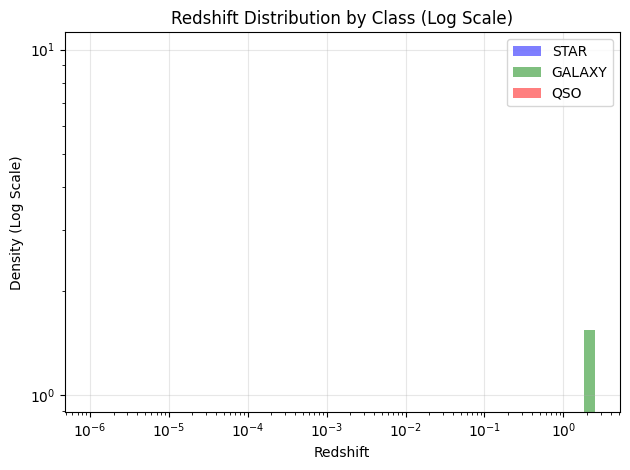

In [ ]:
# --- Self-Check: Task 1 ---
if __name__ == '__main__':
    print("--- [Self-Check] Task 1: Preprocessing ---")
    
    # Dummy DataFrame
    dummy_data = pd.DataFrame({
        'u': [10.0, 20.0, 10.0], 'g': [10.0, 20.0, 10.0], 'r': [10.0, 20.0, 10.0],
        'i': [10.0, 20.0, 10.0], 'z': [10.0, 20.0, 10.0], 'redshift': [0.0, 2.5, 0.0],
        'class': ['STAR', 'GALAXY', 'QSO']
    })
    
    try:
        X_dummy, y_dummy, stats_dummy = preprocess_data(dummy_data)
        
        print(f"Encoded Labels: {y_dummy}")
        if 'u' in stats_dummy:
             print(f"Stats (u): min={stats_dummy['u']['min']}, max={stats_dummy['u']['max']}")
        
        print(f"Normalized X (row 0): {X_dummy[0]}")
        print(f"Normalized X (row 1): {X_dummy[1]}")
        
        if y_dummy[0] == 0 and y_dummy[1] == 1:
            print("[PASS] Encoding correct.")
        else:
            print("[FAIL] Encoding incorrect.")
            
        if X_dummy[0,0] == 0.0 and X_dummy[1,0] == 1.0:
             print("[PASS] Normalization correct.")
        else:
             print("[FAIL] Normalization incorrect.")
             
        print("\n[Test] Plotting Redshift Distribution (Dummy Data)...")
        plot_redshift_distribution(dummy_data)
        plt.show()
             
    except Exception as e:
        print(f"[FAIL] Task 1 failed: {e}")

## Task 2: The Decision Stump (Star vs Non-Star)

<center>
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/e4/Redshift_blueshift.svg/800px-Redshift_blueshift.svg.png" width="600">
<br>
<em>(Redshift and Blueshift. Source: Wikimedia Commons)</em>
</center>

A [**Decision Stump**](https://en.wikipedia.org/wiki/Decision_stump) is a machine learning model consisting of a single decision rule (a tree with depth 1). It uses only one feature and one threshold.

### The Logic
Based on physical intuition, Stars are within our galaxy and don't move away fast (Redshift $\approx$ 0). Deep space objects (Galaxies, Quasars) have high redshift due to [Hubble's Law](https://en.wikipedia.org/wiki/Hubble%27s_law).

**Your Goal:**
Build a classifier that predicts:
$$ \hat{y} = \begin{cases} \text{STAR} (0) & \text{if } \text{redshift} < T \\ \text{NON-STAR} (1) & \text{if } \text{redshift} \ge T \end{cases} $$
*Note: For this task, we treat 'GALAXY'(1) and 'QSO'(2) as 'NON-STAR'(1).*

### Find Optimal Threshold
Iterate through possible thresholds $T$ and find the one that maximizes **Accuracy** on the training set.
*   You can create a set of candidate thresholds based on the values of `redshift` in the training data (e.g., sorted unique values).
*   For each candidate $T$:
    1. Predict 0 if $x < T$, else 1.
    2. Compare with true binary labels (0 vs 1).
    3. Calculate accuracy.
*   Pick the $T$ with the highest accuracy.
*   **Constraints**:
    *   You **MUST** use a loop to iterate through candidate thresholds.
    *   You **MUST NOT** use a loop over samples when predicting or calculating accuracy (use Numpy broadcasting).

---
**Suggested Numpy functions:**
*   `np.unique` : https://numpy.org/doc/stable/reference/generated/numpy.unique.html
*   `np.mean` : https://numpy.org/doc/stable/reference/generated/numpy.mean.html
*   `np.where` : https://numpy.org/doc/stable/reference/generated/numpy.where.html

In [ ]:
class DecisionStump:
    def __init__(self):
        self.threshold = None
        self.feature_idx = 5 # Index of 'redshift' column in X
        
    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        """
        Finds the optimal threshold T for the redshift feature to classify Star (0) vs Non-Star (>0).
        
        Args:
            X: Feature array of shape (N, D).
            y: Label array of shape (N,). (0=Star, 1=Galaxy, 2=QSO).
        """
        # todo start #
        # 1. Convert y to binary target: 0 stays 0 (Star), 1 and 2 become 1 (Non-Star)
        y_binary = np.where(y == 0, 0, 1)  # 0 stays 0; 1/2 become 1

        # 2. Extract redshift column
        redshift = X[:, self.feature_idx]  # Shape: (N,)

        # 3. Define candidate thresholds by sorting unique redshift values
        candidate_thresholds = np.sort(np.unique(redshift))

        best_acc = 0.0
        best_T = None

        # 4. Iterate and find T that maximizes accuracy
        for T in candidate_thresholds:  
            # Predict using T
            preds = np.where(redshift < T, 0, 1)  # 0 if redshift < T, else 1
            
            # Calculate Accuracy
            accuracy = np.mean(preds == y_binary)

            # Update best threshold
            if accuracy > best_acc:
                best_acc = accuracy
                best_T = T
            
        # Store expected threshold in self.threshol
        self.threshold = best_T

        # todo end #
        pass
        #passsss

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predicts binary class (0=Star, 1=Non-Star) using the learned threshold.
        
        Args:
            X: Feature array of shape (M, D).
            
        Returns:
            preds: Array of binary predictions (0 or 1) of shape (M,).
        """
        # todo start #
        # Return array of predictions (0 or 1)

        if self.threshold is None:
            raise ValueError("DecisionStump not fitted yet,, Call fit() first.")
        
        # Extract redshift column
        redshift = X[:, self.feature_idx]
        
        preds = np.where(redshift < self.threshold, 0, 1)
        
        return preds
        
        # todo end #
        pass

### Self-Check: Task 2 (Decision Stump)
Run the following block to test your `DecisionStump` logic.

**Test Scenario:**
*   **Data**: 4 samples. Redshifts: `[0.0, 0.1, 0.8, 0.9]`.
*   **Labels**: `[Star, Star, Galaxy, Galaxy]` -> Binary: `[0, 0, 1, 1]`.
*   **Goal**: The threshold should ideally be 0.8 (the first value of the 'Non-Star' class, or a value separating 0.1 and 0.8).

**Expected Output:**
```text
Optimal Threshold: 0.80
Predictions: [0 0 1 1]
```

In [ ]:
# --- Self-Check: Task 2 ---
if __name__ == '__main__':
    print("--- [Self-Check] Task 2: Decision Stump ---")

    # 4 samples, 2 classes perfectly separable by redshift
    X_stump = np.zeros((4, 6))
    X_stump[:, 5] = [0.0, 0.1, 0.8, 0.9] # Set redshift
    y_stump = np.array([0, 0, 1, 1]) # Star, Star, Galaxy, Galaxy
    
    stump = DecisionStump()
    stump.fit(X_stump, y_stump)
    
    print(f"Optimal Threshold: {stump.threshold}")
    
    preds = stump.predict(X_stump)
    print(f"Predictions: {preds}")
    
    if np.array_equal(preds, [0, 0, 1, 1]):
        print("[PASS] Perfect classification.")
    else:
        print("[FAIL] Incorrect classification.")

--- [Self-Check] Task 2: Decision Stump ---
Optimal Threshold: 0.8
Predictions: [0 0 1 1]
[PASS] Perfect classification.


    ## Task 3: Multi-Class Classification (KNN)

    <center>
    <img src="https://upload.wikimedia.org/wikipedia/commons/e/e7/KnnClassification.svg" width="400">
    <br>
    <em>(KNN Classification Logic. Source: Wikimedia Commons)</em>
    </center>

    While the Decision Stump is great for binary classification, distinguishing Galaxies from Quasars is harder. We need all 6 features (`u, g, r, i, z, redshift`).

    ### Algorithm Recap
    We will use **K-Nearest Neighbors (KNN)** with Euclidean distance.
    $$ d(x, y) = \sqrt{\sum_{i=1}^D (x_i - y_i)^2} $$

    **Task Requirements:**
    1.  **Vectorized Distance**: Compute the $(M, N)$ distance matrix using the expanded squared Euclidean distance.
        $$ \sum_{i=1}^D (x_i - y_i)^2 = \sum_{i=1}^D x_i^2 + \sum_{i=1}^D y_i^2 - 2 \sum_{i=1}^D x_i y_i $$
    2.  **Prediction**: For each test point, find the $K$ nearest training points. predict the majority class (Mode).
        *   **Constraints**: You **MUST NOT** use a Python loop over the test samples $M$. You can use `np.apply_along_axis` with `np.bincount`.
    3.  **Tie-Breaking**: Prefer smallest class index.

    ---
    **Suggested Numpy functions:**
    *   `np.argsort` : https://numpy.org/doc/stable/reference/generated/numpy.argsort.html
    *   `np.bincount` : https://numpy.org/doc/stable/reference/generated/numpy.bincount.html
    *   `np.argmax` : https://numpy.org/doc/stable/reference/generated/numpy.argmax.html
    *   `np.apply_along_axis` : https://numpy.org/doc/stable/reference/generated/numpy.apply_along_axis.html
    *   `np.sum` : https://numpy.org/doc/stable/reference/generated/numpy.sum.html
    *   `np.dot` : https://numpy.org/doc/stable/reference/generated/numpy.dot.html
    *   `np.maximum` : https://numpy.org/doc/stable/reference/generated/numpy.maximum.html

In [ ]:
class KNN:
    # You can change the k value to see the prediction performance differences!
    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        """
        Lazy learning: just store the data.
        
        Args:
            X: Training features of shape (N, D).
            y: Training labels of shape (N,).
        """
        self.X_train = X    
        self.y_train = y

    def predict(self, X_test: np.ndarray) -> np.ndarray:
        """
        Predicts labels for test data.
        
        Args:
            X_test: Test features of shape (M, D).
            
        Returns:
            preds: Predicted labels of shape (M,).
        """
        # todo start #
        # 1. Compute vectorized distance matrix (M, N) 
        #    (Use squared Euclidean distance trick: a^2 + b^2 - 2ab)
        X_train_sq = np.sum(self.X_train ** 2, axis=1)
        X_test_sq = np.sum(X_test ** 2, axis=1)
        
        # Compute dot product (M, N) and squared distance matrix
        dot_product = np.dot(X_test, self.X_train.T)
        
        # X_test_sq[:, None]：把 (M,) 变成 (M,1)，才能和 (N,) 的 X_train_sq 广播相加 very important

        dist_sq = X_test_sq[:, None] + X_train_sq - 2 * dot_product
        dist_sq = np.maximum(dist_sq, 0.0)  

        # 2. Get top-k nearest neighbors indices
        k_indices = np.argsort(dist_sq, axis=1)[:, :self.k]

        # 3. Predict label using majority vote (mode) for each test sample
        k_neighbor_labels = self.y_train[k_indices]  # shape: (M, k)

        def majority_vote(row):
            counts = np.bincount(row)
            return np.argmax(counts)  # argmax returns smallest index in case of tie
        
        # Apply majority vote to all test samples 
        preds = np.apply_along_axis(majority_vote, axis=1, arr=k_neighbor_labels)
        return preds

        # todo end #
        pass

### Self-Check: Task 3 (KNN)
Run the following block to test your `KNN` implementation.

**Test Scenario:**
*   **Train**: Group A at (0,0), Group B at (5,5).
*   **Test**: Point (0.1, 0.1) should be Group A. Point (4.9, 4.9) should be Group B.

**Expected Output:**
```text
KNN Predictions: [0 1]
```

In [ ]:
# --- Self-Check: Task 3 ---
if __name__ == '__main__':
    print("--- [Self-Check] Task 3: KNN ---")
    
    # Train: 2 clusters
    X_train_knn = np.array([
        [0,0], [0.1,0.1], [0,0.1],
        [5,5], [5.1,5.1], [5,5.1]
    ])
    y_train_knn = np.array([0,0,0, 1,1,1])
    
    # Test
    X_test_knn = np.array([
        [0.05, 0.05], # Near 0
        [5.05, 5.05]  # Near 1
    ])
    
    knn = KNN(k=3)
    knn.fit(X_train_knn, y_train_knn)
    preds = knn.predict(X_test_knn)
    
    print(f"KNN Predictions: {preds}")
    
    if np.array_equal(preds, [0, 1]):
        print("[PASS] KNN Predictions correct.")
    else:
        print("[FAIL] KNN Predictions incorrect.")

a## Task 4: Unsupervised Learning (K-Means) with Optimal K

<center>
<img src="https://upload.wikimedia.org/wikipedia/commons/e/ea/K-means_convergence.gif" width="400">
<br>
<em>(K-Means Iterative Process. Source: Wikimedia Commons)</em>
</center>

Let's see if the objects naturally cluster into Stars, Galaxies, and Quasars without labels.
We will also verify if **K=3** is indeed the optimal number of clusters using the [**Within-Cluster Sum of Squares (WCSS)**](https://en.wikipedia.org/wiki/K-means_clustering).

$$ WCSS = \sum_{i=1}^N \min_{j} ||x^{(i)} - \mu^{(j)}||^2 $$

### Task 4.1: Core K-Means + Programmatic Elbow
1.  Implement **K-Means** exactly as in the lecture/tutorial.
2.  **Iterate K**: Run K-Means for $K$ in a given range.
3.  **Compute WCSS**: For each $K$, calculate the Within-Cluster Sum of Squares (Sum of squared Euclidean distances from each point to its assigned centroid).
4.  **Find Optimal K**: Use `np.sort` (or `np.argsort`) on the WCSS values (or their changes) to programmatically identify the ["Elbow"](https://en.wikipedia.org/wiki/Elbow_method_(clustering)) or optimal K.
5.  **Verification**: Check if the optimal K found is equal to **3**.

### Task 4.2: Visualize the Elbow (WCSS vs K)
To visually confirm the "Elbow", you should plot the WCSS values against K.
*   **Requirement**: Implement a separate function `plotting_WCSS` for plotting.
*   **Plotting Standards**:
    *   **Title**: 'Elbow Method: WCSS vs K'
    *   **X-Label**: 'Number of Clusters (K)'
    *   **Y-Label**: 'WCSS'
    *   **Style**: Use markers (e.g., `marker='o'`) to indicate the WCSS for each K.
    *   **Highlight**: Plot a distinct marker or vertical line at the `optimal_k`.
    *   **Grid**: Show a grid for better readability.

**Note**:
*   **Loops**: You MUST use a main loop for K-Means iterations (until convergence). However, you **must vectorize** the cluster assignment and centroid update steps.
*   **Empty Clusters**: When updating centroids, some clusters might become empty. Handle this by **retaining the previous centroid**.
*   **Optimal K**: Use the maximum geometric distance from each $(K, WCSS)$ point to the line connecting the first and last points. The perpendicular distance from a point $(x_0,y_0)$ to the line through $(x_1,y_1)$ and $(x_2,y_2)$ is given by
    $$
    d = \frac{|(x_2 - x_1)(y_1 - y_0) - (x_1 - x_0)(y_2 - y_1)|}{\sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}}.
    $$
    You should take care of the **division-by-zero** problem. What is the scenario behind?
*   **Seed**: You MUST use `seed=42` when initializing `KMeans` in `find_optimal_k` to ensure reproducibility.

**Suggested Numpy functions:**
*   `np.random.choice` : https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html
*   `np.argmin` : https://numpy.org/doc/stable/reference/generated/numpy.argmin.html 
*   `np.sum` : https://numpy.org/doc/stable/reference/generated/numpy.sum.html
*   `np.dot` : https://numpy.org/doc/stable/reference/generated/numpy.dot.html 
*   `np.min` : https://numpy.org/doc/stable/reference/generated/numpy.min.html 
*   `np.eye` : https://numpy.org/doc/stable/reference/generated/numpy.eye.html
*   `np.maximum` : https://numpy.org/doc/stable/reference/generated/numpy.maximum.html
*   `np.allclose` : https://numpy.org/doc/stable/reference/generated/numpy.allclose.html
*   `np.abs` : https://numpy.org/doc/stable/reference/generated/numpy.absolute.html
*   `np.sqrt` : https://numpy.org/doc/stable/reference/generated/numpy.sqrt.html
*   `np.argsort` : https://numpy.org/doc/stable/reference/generated/numpy.argsort.html

In [17]:
class KMeans:
    def __init__(self, k=3, max_iters=100, seed=42):
        self.k = k
        self.max_iters = max_iters
        self.seed = seed
        self.centroids = None
        self.wcss = 0.0

    def fit(self, X: np.ndarray) -> Tuple[np.ndarray, float]:
        """
        Runs K-Means clustering.
        
        Args:
            X: Input data array of shape (N, D).
        
        Returns:
            clusters: Array of shape (N,) containing cluster indices.
            wcss: The Within-Cluster Sum of Squares.
        """
        # todo start #
        np.random.seed(self.seed)
        N, D = X.shape
        
        # Initialize centroids (randomly)
        init_indices = np.random.choice(N, size=self.k, replace=False)
        self.centroids = X[init_indices].copy()  # Shape: (k, D)
        
        # Initialize clusters
        clusters = np.zeros(N, dtype=int)

        # Loop until convergence or max_iters:
        for _ in range(self.max_iters):
            previous_centroids = self.centroids.copy()
            # 1. Assign clusters (vectorized distance)
            x_sq = np.sum(X **2, axis=1)[:, None]  # (N, 1)
            centroid_sq = np.sum(self.centroids** 2, axis=1)[None, :]  # (1, k)
            dot_product = np.dot(X, self.centroids.T)  # (N, k)
            dist_sq = x_sq + centroid_sq - 2 * dot_product  # (N, k)
            # dist_sq = np.maximum(dist_sq, 0.0)  

            # Assign each point to the closest centroid (argmin of distances)
            clusters = np.argmin(dist_sq, axis=1)  # (N,)

            # 2. Update centroids (mean)
            mask = np.zeros((N, self.k), dtype=bool)
            mask[np.arange(N), clusters] = True

            sum_pts = mask.T @ X          # (k, D)
            cnt_pts = mask.sum(axis=0)    # (k,)

            # 空簇随机重选
            empty = cnt_pts == 0
            if empty.any():
                self.centroids[empty] = X[np.random.choice(N, empty.sum())]

            # update
            ok = cnt_pts > 0
            self.centroids[ok] = sum_pts[ok] / cnt_pts[ok, None]

            #self.centoroid is now the new one , comparing it with the previous one
            # 3. Check for convergence
            if np.allclose(self.centroids, previous_centroids, atol=1e-4):
                break 
        
        #after convergence , evaluation
        # Calculate final WCSS
        
        # Expand clusters/centroids for broadcasting
        x_expanded = X[:, None, :]  # (N, 1, D)
        centroid_expanded = self.centroids[None, :, :]  # (1, k, D)
        
        #  mask for each point's assigned centroid
        cluster_mask = np.zeros((N, self.k), dtype=bool)
        cluster_mask[np.arange(N), clusters] = True
        cluster_mask_expanded = cluster_mask[:, :, None]  # (N, k, 1)
        
        # Calculate squared distance only for the assigned centroid
        dist_sq = np.sum((x_expanded - centroid_expanded) **2, axis=2)  # (N, k)
        self.wcss = np.sum(dist_sq[cluster_mask])  
        
    # kinda burnout when doing this
    
        # todo end #
        return clusters, self.wcss


def find_optimal_k(X: np.ndarray, k_range: range) -> Tuple[int, np.ndarray]:
    """
    Finds optimal K by scanning a range and calculating the distance.
    You can use loop here, we don't detect in this function.
    You can assume that the len(k_range) >= 3 to make this function meaningful
    
    Args:
        X: Input data.
        k_range: List/Range of K values to test.
        
    Returns:
        optimal_k: The estimated optimal K.
        wcss_history: List of WCSS values for each K.
    """
    wcss_history = []
    
    # todo start #
    # 1. Iterate over k_range
    for k in k_range:
    # 2. Fit KMeans and collect WCSS
        kmeans = KMeans(k=k, max_iters=100, seed=42)
        _, wcss = kmeans.fit(X)
        wcss_history.append(wcss)
    
    wcss_history = np.array(wcss_history)
    k_values = np.array(list(k_range)) 

    # 3. Calculate the distance of each point
    if len(wcss_history) < 3:
        optimal_k = k_values[0] 
    else:
        # Convert to coordinates for line distance calculation
        x = k_values
        y = wcss_history
        
        # Line 
        x0, y0 = x[0], y[0]
        x1, y1 = x[-1], y[-1]
        
        # calculate perpendicular distance from each point to the line
        numerator = np.abs((y1 - y0) * x - (x1 - x0) * y + x1 * y0 - y1 * x0)
        denominator = np.sqrt((y1 - y0)** 2 + (x1 - x0)**2)
        distances = numerator / denominator
        
        #optimal K = the K with maximum distance (elbow point!!!!
        optimal_idx = np.argmax(distances)
        optimal_k = k_values[optimal_idx]

    
    # optimal_k = 0
    # todo end #
    
    return optimal_k, wcss_history

def plot_WCSS(optimal_k: int, wcss_history: np.ndarray) -> None:
    """
    Plots WCSS vs K and highlights the selected optimal K.

    Args:
        optimal_k: The optimal K returned by find_optimal_k.
        wcss_history: WCSS values ordered by K=1..len(wcss_history).
    """
    # todo start #
    # 1. Build x-axis K values from wcss_history length
    k_values = np.arange(1, len(wcss_history) + 1)

    # 2. Plot WCSS curve with marker='o'
    plt.figure(figsize=(10, 6))
    plt.plot(k_values, wcss_history, marker='o', linestyle='-', color='blue', linewidth=2, markersize=8)
    
    # 3. Set title/xlabel/ylabel and enable grid
    plt.title('Elbow Method: WCSS vs K', fontsize=14)
    plt.xlabel('Number of Clusters (K)', fontsize=12)
    plt.ylabel('WCSS', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

    # 4. Highlight optimal_k with a vertical line or distinct marker
    optimal_idx = optimal_k - 1  # K starts at 1, index starts at 0
    plt.scatter(optimal_k, wcss_history[optimal_idx], color='red', s=150, zorder=5, label=f'Optimal K = {optimal_k}')
    plt.axvline(x=optimal_k, color='red', linestyle='--', linewidth=2)
    
    # todo end #
    pass

### Self-Check: Task 4 (K-Means with Optimal K)
Run the following block to test your `find_optimal_k` and `KMeans` implementation.

**Test Scenario:**
*   **Data**: 3 distinct cloud of points (Clearly separable).
*   **Goal**: 
    1.  Search K from 1 to 5.
    2.  Check if Optimal K is detected as **3**.
    3.  Check if K=3 clustering result is balanced.

**Expected Output:**

```text
Testing Optimal K finding...
Range to test: range(1, 6)
Optimal K found: 3
[PASS] Optimal K correctly identified as 3.
Cluster Counts with K=3: [3 3 3]
```

--- [Self-Check] Task 4: K-Means with Optimal K ---
Testing Optimal K finding...


/var/folders/jc/8r_cxn9j5fncd5rm5gd545q80000gn/T/ipykernel_7731/541581894.py:162: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)


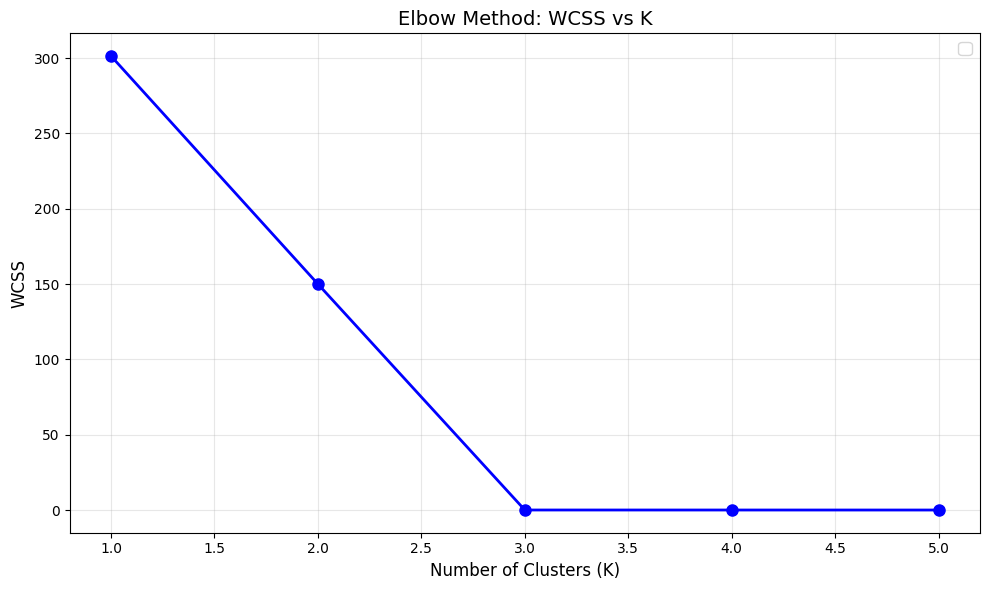

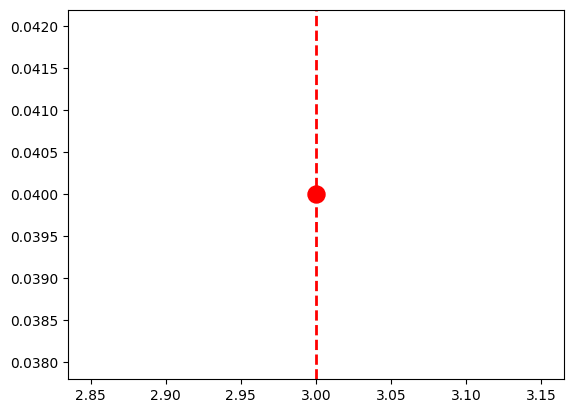

Range to test: range(1, 6)
Optimal K found: 3
[PASS] Optimal K correctly identified as 3.
Cluster Counts with K=3: [3 3 3]
[PASS] Groups separated perfectly.


In [18]:
# --- Self-Check: Task 4 ---
if __name__ == '__main__':
    print("--- [Self-Check] Task 4: K-Means with Optimal K ---")
    
    # 3 Groups (Clear separation, Equilateral Triangle Shape)
    # Group 1: (0,0)
    # Group 2: (10,0)
    # Group 3: (5, 8.66) -> Approx Equilateral Triangle to ensure K=2 is bad fit
    X_km = np.array([
        [0,0], [0.1,0], [0,0.1],
        [10,0], [10.1,0], [10,0.1],
        [5,8.7], [5.1,8.7], [5,8.8] 
    ])
    
    print("Testing Optimal K finding...")
    k_range_test = range(1, 6)
    
    opt_k, history = find_optimal_k(X_km, k_range_test)
    plot_WCSS(opt_k, history)
    plt.show() # Should display the elbow plot
    
    print(f"Range to test: {k_range_test}")
    print(f"Optimal K found: {opt_k}")
    
    if opt_k == 3:
        print("[PASS] Optimal K correctly identified as 3.")
    else:
        print(f"[FAIL] Optimal K identified as {opt_k}, expected 3.")
        
    # Check clustering with optimal K
    mkmeans = KMeans(k=3, seed=42) # Should use opt_k if correct, but hardcode 3 for safety check of KMeans logic itself
    clusters, _ = mkmeans.fit(X_km)
    counts = np.bincount(clusters)
    print(f"Cluster Counts with K=3: {counts}")
    
    if len(counts) == 3 and np.all(counts == 3):
        print("[PASS] Groups separated perfectly.")
    else:
        print("[FAIL] Groups mixed or standard failed.")

## Task 5: Evaluation Metrics (Per-Class)

<center>
<svg width="520" height="240" viewBox="0 0 520 240" xmlns="http://www.w3.org/2000/svg" role="img" aria-label="Confusion matrix layout">
  <rect x="0" y="0" width="520" height="240" fill="white"/>
  <text x="280" y="24" font-size="16" text-anchor="middle" fill="#2F3B52">Predicted label</text>
  <text x="28" y="140" font-size="16" text-anchor="middle" fill="#2F3B52" transform="rotate(-90 28 140)">True label</text>
  <rect x="140" y="50" width="280" height="160" fill="none" stroke="#2F3B52" stroke-width="2"/>
  <line x1="280" y1="50" x2="280" y2="210" stroke="#2F3B52" stroke-width="2"/>
  <line x1="140" y1="130" x2="420" y2="130" stroke="#2F3B52" stroke-width="2"/>
  <text x="210" y="92" font-size="18" text-anchor="middle" fill="#4C78A8">TP</text>
  <text x="350" y="92" font-size="18" text-anchor="middle" fill="#F58518">FP</text>
  <text x="210" y="172" font-size="18" text-anchor="middle" fill="#F58518">FN</text>
  <text x="350" y="172" font-size="18" text-anchor="middle" fill="#4C78A8">TN</text>
  <text x="210" y="44" font-size="13" text-anchor="middle" fill="#2F3B52">pred=1</text>
  <text x="350" y="44" font-size="13" text-anchor="middle" fill="#2F3B52">pred=0</text>
  <text x="132" y="92" font-size="13" text-anchor="end" fill="#2F3B52">true=1</text>
  <text x="132" y="172" font-size="13" text-anchor="end" fill="#2F3B52">true=0</text>
</svg>
<br>
<em>(Confusion Matrix: The basis for Precision and Recall)</em>
</center>

Accuracy is misleading when classes are imbalanced (Quasars are rare!). We need **Precision**, **Recall**, and **F1-Score** for *each* class.

**Formulas (for a specific class $C$):**
*   **TP**: True Positive (Predicted $C$, True $C$)
*   **FP**: False Positive (Predicted $C$, True $\neq C$)
*   **FN**: False Negative (Predicted $\neq C$, True $C$)
*   **ε**: A small value preventing division by zero ($\epsilon = 1e-9$)

$$ \text{Precision}_C = \frac{TP}{TP + FP + \epsilon} $$
$$ \text{Recall}_C = \frac{TP}{TP + FN + \epsilon} $$
$$ \text{F1}_C = 2 \times \frac{\text{Precision}_C \times \text{Recall}_C}{\text{Precision}_C + \text{Recall}_C + \epsilon} $$

**Requirement:**
Implement `evaluate_per_class` which returns a DataFrame or Dictionary showing these 3 metrics for 'STAR', 'GALAXY', and 'QSO'.
*   **Constraints**: You **MUST NOT** use a Python loop to iterate over the classes. You should compute the Confusion Matrix efficiently using `np.bincount`.

**Suggested Numpy/Pandas functions:**
*   `np.bincount` : https://numpy.org/doc/stable/reference/generated/numpy.bincount.html
*   `np.diag` : https://numpy.org/doc/stable/reference/generated/numpy.diag.html
*   `np.sum` : https://numpy.org/doc/stable/reference/generated/numpy.sum.html
*   `np.stack` : https://numpy.org/doc/stable/reference/generated/numpy.stack.html
*   `np.isclose` : https://numpy.org/doc/stable/reference/generated/numpy.isclose.html

In [ ]:
def evaluate_per_class(y_true: np.ndarray, y_pred: np.ndarray, class_names: List[str]) -> pd.DataFrame:
    """
    Computes Precision, Recall, and F1 for each class.
    
    Args:
        y_true: True labels of shape (N,).
        y_pred: Predicted labels of shape (N,).
        class_names: List of class names (e.g., ['STAR', 'GALAXY', 'QSO']).
        
    Returns:
        metrics_df: A DataFrame where Index=Class and Columns=[Precision, Recall, F1].
    """
    # === Do not modify this ===
    metrics = []
    epsilon = 1e-9
    num_classes = len(class_names)
    # === Do not modify this ===
    
    # todo start #
    # Vectorized Metric Calculation (No explicit class loop needed for logic, mostly)
    
    # 1. Compute Confusion Matrix (C x C)
    # Rows=True, Cols=Pred
    # Trick: Use bincount on flattened index (true * C + pred)
    
     # Step 1: convert ( true, pred) pairs to unique flat indices smart !!!
    flat_indices = y_true * num_classes + y_pred
    
    # 2: count occurrences to build flat confusion matrix
    cm_flat = np.bincount(flat_indices, minlength=num_classes * num_classes)
    
    # 3: Reshape to C×C confusion matrix ('rows=true,cols=pred')
    conf_matrix = cm_flat.reshape(num_classes, num_classes)

    # 2. Extract TP, FP, FN
    TP = np.diag(conf_matrix)                  
    FP = np.sum(conf_matrix, axis=0) - TP      
    FN = np.sum(conf_matrix, axis=1) - TP 
    
    # 3. Compute Metrics
    precision = TP / (TP + FP + epsilon)
    recall = TP / (TP + FN + epsilon)
    f1 = 2 * (precision * recall) / (precision + recall + epsilon)
    
    # 4. Format Output
    data=np.stack([precision, recall, f1], axis=1)
    metrics=data
    # return pd.DataFrame(
    #     data=data,
    #     index=class_names,
    #     columns=['Precision', 'Recall', 'F1']
    # )
    # todo end #
    
    return pd.DataFrame(metrics, index=class_names, columns=['Precision', 'Recall', 'F1'])

### Self-Check: Task 5 (Metrics)
Run the following block to test your metric calculation.

**Test Scenario:**
*   **True**: `[0, 1, 1, 2]`
*   **Pred**: `[0, 1, 2, 2]`
*   **Analysis for Class 1**:
    *   True 1s: 2 instances.
    *   Pred 1s: 1 instance.
    *   TP=1 (Index 1), FN=1 (Index 2 predicted as 2), FP=0.
    *   Precision = 1/1 = 1.0. Recall = 1/2 = 0.5.

**Expected Output:**
```text
        Precision  Recall        F1
Class0        1.0     1.0  1.000000
Class1        1.0     0.5  0.666667
Class2        0.5     1.0  0.666667
```

In [13]:
# --- Self-Check: Task 5 ---
if __name__ == '__main__':
    print("--- [Self-Check] Task 5: Metrics ---")
    
    y_true_m = np.array([0, 1, 1, 2])
    y_pred_m = np.array([0, 1, 2, 2])
    classes = ['Class0', 'Class1', 'Class2']
    
    df = evaluate_per_class(y_true_m, y_pred_m, classes)
    print(df)
    
    # Check Class 1
    # TP=1, FP=0, FN=1 -> Prec=1.0, Rec=0.5
    p1 = df.loc['Class1', 'Precision']
    r1 = df.loc['Class1', 'Recall']
    
    if np.isclose(p1, 1.0) and np.isclose(r1, 0.5):
        print("[PASS] Metrics calculation correct.")
    else:
        print(f"[FAIL] Metrics incorrect. Got P={p1}, R={r1}")

--- [Self-Check] Task 5: Metrics ---
        Precision  Recall        F1
Class0        1.0     1.0  1.000000
Class1        1.0     0.5  0.666667
Class2        0.5     1.0  0.666667
[PASS] Metrics calculation correct.


## Main Execution Block
Run this pipeline to verify your implementation.

**Expected Output:**

```text
--- Task 2: Decision Stump (Star vs Non-Star) ---
Optimal Redshift Threshold found: 0.0018
Decision Stump Accuracy: 0.9950
[SUCCESS] Decision Stump Accuracy is acceptable.

--- Task 3: K-Nearest Neighbors (k = 5) ---
First 20 KNN predictions: [2 1 0 0 1 1 0 0 1 0 1 1 1 1 0 0 1 1 1 1]

--- Task 5: Metrics (k = 5) ---
        Precision    Recall        F1
STAR     0.927914  0.975806  0.951258
GALAXY   0.966154  0.928994  0.947210
QSO      0.989796  0.932692  0.960396
[SUCCESS] STAR classification F1-Score is high.

--- Task 4: K-Means Clustering ---
Finding optimal K (Elbow Method)...
Optimal K detected: 3
[SUCCESS] Optimal K matches the expected number of classes (3).
Final K-Means run with K=3. WCSS: 133.01
Cluster counts: [1648 3485  467]
```

**Note**: Small variation can happen if your implementation handles ties/float rounding differently, but you should be very close if the logic is correct.

In [ ]:
if __name__ == '__main__':
    # 1. Load Data
    full_df = pd.read_csv(os.path.join(DATA_PATH, 'train.csv'))
    
    # 2. Split (80/20) - Manual shuffle
    np.random.seed(0)
    indices = np.random.permutation(len(full_df))
    split = int(0.8 * len(full_df))
    train_df = full_df.iloc[indices[:split]]
    val_df = full_df.iloc[indices[split:]]
    
    # 3. Preprocess
    print("--- Preprocessing ---")
    X_train, y_train, stats = preprocess_data(train_df)
    X_val, y_val, _ = preprocess_data(val_df, stats=stats)
    
    # 4. Visualization (Task 1.2)
    print("\n--- Visualizing Redshift ---")
    plot_redshift_distribution(full_df)
    plt.show()
    
    # 5. Decision Stump (Task 2)
    print("\n--- Task 2: Decision Stump (Star vs Non-Star) ---")
    stump = DecisionStump()
    stump.fit(X_train, y_train)
    print(f"Optimal Redshift Threshold found: {stump.threshold:.4f}")
    
    # Evaluate Stump
    stump_preds = stump.predict(X_val)
    # Map y_val to binary for evaluation
    y_val_binary = np.where(y_val == 0, 0, 1)
    acc_stump = np.mean(stump_preds == y_val_binary)
    print(f"Decision Stump Accuracy: {acc_stump:.4f}")
    
    # Success Check (Expect high accuracy since Redshift is strong feature for Star vs NonStar)
    if acc_stump > 0.90:
        print("[SUCCESS] Decision Stump Accuracy is acceptable.")
    else:
        print("[WARNING] Decision Stump Accuracy is lower than expected.")
    
    # 6. KNN (Task 3)
    print("\n--- Task 3: K-Nearest Neighbors ---")
    knn = KNN()
    knn.fit(X_train, y_train)
    knn_preds = knn.predict(X_val)
    print(f"First 20 KNN predictions: {knn_preds[:20]}")
    
    # 7. Metrics (Task 5)
    print("\n--- Task 5: Metrics ---")
    metrics_df = evaluate_per_class(y_val, knn_preds, ['STAR', 'GALAXY', 'QSO'])
    print(metrics_df)
    
    # Success Check (Expect Star F1 to be very high)
    star_f1 = metrics_df.loc['STAR', 'F1']
    if star_f1 > 0.95:
         print("[SUCCESS] STAR classification F1-Score is high.")
    
    # 8. K-Means (Task 4)
    print("\n--- Task 4: K-Means Clustering ---")
    
    # 4.1 Search for Optimal K
    print("Finding optimal K (Elbow Method)...")
    k_range = range(1, 10)
    optimal_k, wcss_history = find_optimal_k(X_train, k_range)
    plot_WCSS(optimal_k, wcss_history)
    plt.show()
    print(f"Optimal K detected: {optimal_k}")
    
    if optimal_k == 3:
        print("[SUCCESS] Optimal K matches the expected number of classes (3).")
    else:
        print(f"[WARNING] Optimal K ({optimal_k}) different from expected (3).")
        
    # 4.2 Run K-Means with K=3 (or optimal)
    kmeans = KMeans(k=optimal_k)
    clusters, wcss_final = kmeans.fit(X_train)
    print(f"Final K-Means run with K={optimal_k}. WCSS: {wcss_final:.2f}")
    print("Cluster counts:", np.bincount(clusters))

NameError: name 'pd' is not defined